# Naive Bayes — prepoznavanje emocija iz govora

Klasifikacija emocija na RAVDESS skupu podataka pomoću **Gaussian Naive Bayes** klasifikatora. Model pretpostavlja da su karakteristike uslovno nezavisne po klasi i da svaka prati normalnu (Gauss-ovu) raspodelu.

## Karakteristike i podela na skupove

Iste karakteristike kao kod KNN modela (mean/std/max Mel-spektrograma, 384 vrednosti) i ista actor-independent podela (16/4/4 glumaca za train/val/test, bez preklapanja).

## Treniranje

Zbog velikog broja karakteristika (384) i njihove međusobne korelisanosti (što narušava pretpostavku nezavisnosti Naive Bayes-a), prvo se primenjuje **PCA** radi smanjenja dimenzionalnosti. Broj PCA komponenti se bira pomoću `GridSearchCV` (20/50/100/150), zajedno sa ostatkom modela u jednom `Pipeline`-u, nad train+val skupom. Test skup se koristi isključivo za završnu evaluaciju.

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns

X_trainval = np.load("data/processed_data/knn_and_nb/X_trainval.npy")
y_trainval = np.load("data/processed_data/knn_and_nb/y_trainval.npy")
X_test = np.load("data/processed_data/knn_and_nb/X_test.npy")
y_test = np.load("data/processed_data/knn_and_nb/y_test.npy")
le = joblib.load("data/processed_data/knn_and_nb/label_encoder.pkl")

scaler = StandardScaler()
X_trainval_scaled = scaler.fit_transform(np.nan_to_num(X_trainval, nan=0.0))
X_test_scaled = scaler.transform(np.nan_to_num(X_test, nan=0.0))

nb_pipeline = Pipeline([('pca', PCA()), ('nb', GaussianNB())])
param_grid = {'pca__n_components': [20, 50, 100, 150]}
grid = GridSearchCV(nb_pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid.fit(X_trainval_scaled, y_trainval)

nb_final = grid.best_estimator_
print("Best params (PCA n_components):", grid.best_params_)

y_test_pred = nb_final.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred, target_names=le.classes_))


In [ ]:
os.makedirs("models/naive_bayes", exist_ok=True)
joblib.dump(nb_final, "models/naive_bayes/naive_bayes_model.pkl")
joblib.dump(scaler, "models/naive_bayes/scaler.pkl")
joblib.dump(le, "models/naive_bayes/label_encoder.pkl")

cm = confusion_matrix(y_test, y_test_pred, labels=np.arange(len(le.classes_)))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Naive Bayes - Test Confusion Matrix')
plt.savefig("models/naive_bayes/test_confusion_matrix.png")
plt.show()


## Rezultati

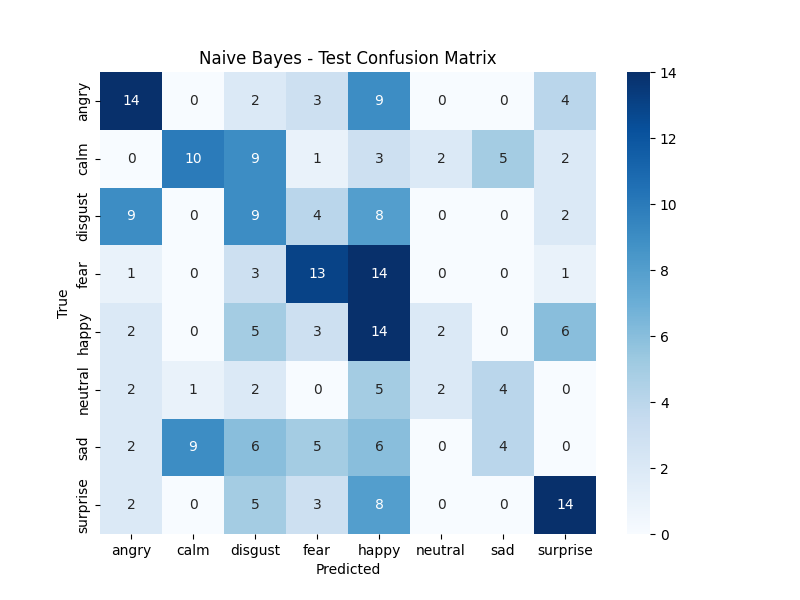

In [2]:
from IPython.display import Image, display
display(Image(filename="models/naive_bayes/test_confusion_matrix.png"))


## Zaključak

Naive Bayes model postiže **33.3%** tačnosti na test skupu (actor-independent) — nešto niže od KNN-a, i najniže od sva tri klasična modela. Ovo je očekivano: pretpostavka o nezavisnosti karakteristika, na kojoj se Naive Bayes zasniva, ne odgovara stvarnosti kod Mel-spektrogramskih statistika, koje su međusobno jako korelisane (susedni mel-frekvencijski pojasevi nose sličnu informaciju). PCA delimično ublažava ovaj problem dekorelacijom, ali ne uklanja fundamentalno ograničenje modela za ovaj tip podataka.